1. Data Preparation:

Download the “Heart Disease UCI” dataset.
Perform exploratory data analysis (EDA) to understand the dataset.
Preprocess the data: handle missing values if any, encode categorical variables, and scale the features.

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df =pd.read_csv('heart_disease_uci.csv')

In [66]:
df['num'].head(7)

0    0
1    2
2    1
3    0
4    0
5    0
6    3
Name: num, dtype: int64

In [67]:
print(f'first 7 row: \n{df.head(7)}')

first 7 row: 
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   
5   6   56    Male  Cleveland  atypical angina     120.0  236.0  False   
6   7   62  Female  Cleveland     asymptomatic     140.0  268.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   
5          norm

In [68]:
print(f'stats : \n{df.describe().round(2)}')

stats : 
           id     age  trestbps    chol  thalch  oldpeak      ca     num
count  920.00  920.00    861.00  890.00  865.00   858.00  309.00  920.00
mean   460.50   53.51    132.13  199.13  137.55     0.88    0.68    1.00
std    265.73    9.42     19.07  110.78   25.93     1.09    0.94    1.14
min      1.00   28.00      0.00    0.00   60.00    -2.60    0.00    0.00
25%    230.75   47.00    120.00  175.00  120.00     0.00    0.00    0.00
50%    460.50   54.00    130.00  223.00  140.00     0.50    0.00    1.00
75%    690.25   60.00    140.00  268.00  157.00     1.50    1.00    2.00
max    920.00   77.00    200.00  603.00  202.00     6.20    3.00    4.00


In [69]:
print(f'shape : {df.shape}')
print()
print('data columns')
df.columns.tolist()

shape : (920, 16)

data columns


['id',
 'age',
 'sex',
 'dataset',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalch',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'num']

age --Patient age

sex --Male = 1, Female = 0

cp--Chest pain type

trestbps--Resting blood pressure

chol--Serum cholesterol

fbs--Fasting blood sugar

restecg--Resting ECG results

thalach--Maximum heart rate achieved

exang--Exercise-induced angina

old_peak --ST depression during exercise

slope--Slope of ST segment

ca--Number of major vessels

thal--Thalassemia condition

In [70]:

print(f'data info :\n{df.info()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
data info :
None


In [71]:
print(f'shape :{df.shape}')
print()
print(f'missing value: {df.isna().sum()}')

shape :(920, 16)

missing value: id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [72]:
df=df.drop(columns ='ca')

In [73]:
print(f"dataset categories \n{df['dataset'].unique()}\n")
print(f"resting ECG results categories : \n{df['restecg'].unique()}\n")
print(f"chest pain type : \n{df['cp'].unique()})")

dataset categories 
['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']

resting ECG results categories : 
['lv hypertrophy' 'normal' 'st-t abnormality' nan]

chest pain type : 
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina'])


<Axes: xlabel='thal', ylabel='count'>

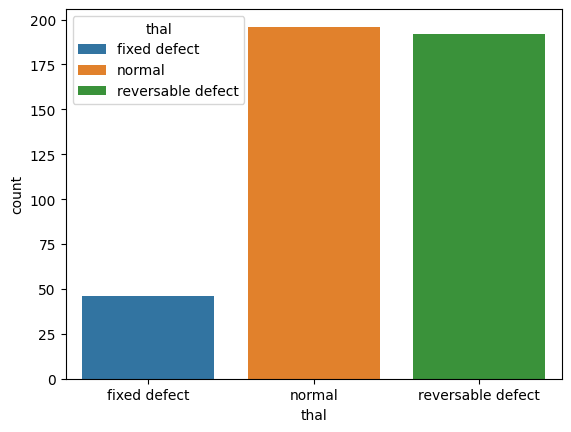

In [74]:
sns.countplot(data =df, x ='thal' , hue ='thal')

In [75]:
df['thal']=df['thal'].fillna('unknown')
df['thal'].unique()

array(['fixed defect', 'normal', 'reversable defect', 'unknown'],
      dtype=object)

<Axes: xlabel='thal', ylabel='count'>

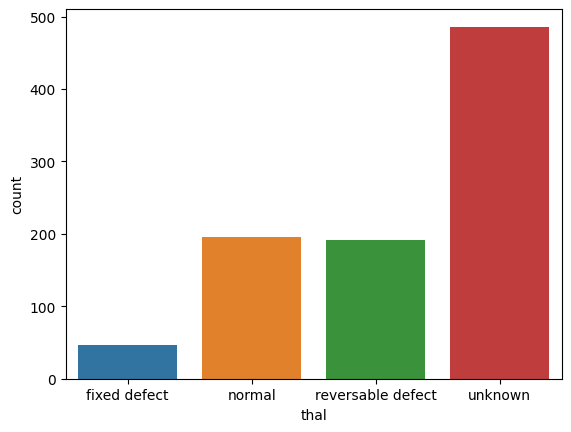

In [76]:
sns.countplot(data =df, x ='thal', hue ='thal')

In [77]:
df =df.drop(columns ='thal')

<Axes: xlabel='slope', ylabel='count'>

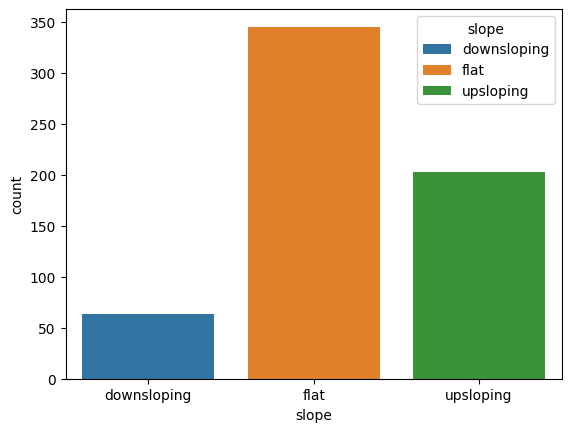

In [78]:
sns.countplot(data =df, x ='slope', hue ='slope')

<Axes: xlabel='slope', ylabel='count'>

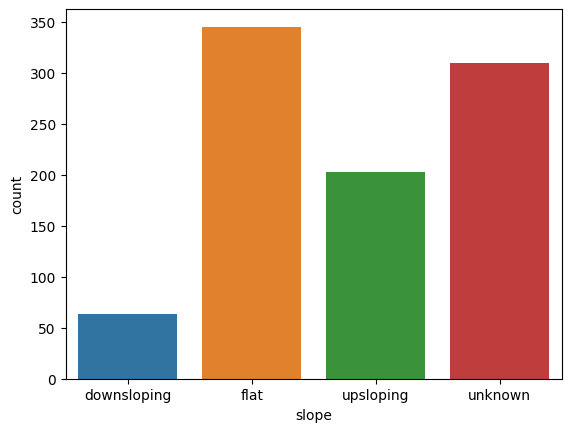

In [79]:
df['slope']=df['slope'].fillna('unknown')
sns.countplot(data = df, x ='slope', hue = 'slope')

In [80]:
df[df['fbs'].isna()]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,num
330,331,38,Female,Hungary,atypical angina,120.0,275.0,NaN,normal,129.0,False,0.0,unknown,0
384,385,46,Male,Hungary,non-anginal,150.0,163.0,NaN,normal,116.0,False,0.0,unknown,0
410,411,49,Male,Hungary,asymptomatic,120.0,297.0,NaN,normal,132.0,False,1.0,flat,0
434,435,53,Female,Hungary,atypical angina,113.0,468.0,NaN,normal,127.0,False,0.0,unknown,0
447,448,54,Female,Hungary,atypical angina,140.0,309.0,NaN,st-t abnormality,140.0,False,0.0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
776,777,53,Male,VA Long Beach,asymptomatic,154.0,0.0,NaN,st-t abnormality,140.0,True,1.5,flat,2
781,782,61,Male,VA Long Beach,asymptomatic,110.0,0.0,NaN,normal,108.0,True,2.0,downsloping,2
782,783,57,Male,VA Long Beach,asymptomatic,130.0,311.0,NaN,st-t abnormality,148.0,True,2.0,flat,1
785,786,69,Male,VA Long Beach,non-anginal,140.0,0.0,NaN,st-t abnormality,118.0,False,2.5,downsloping,2


In [81]:
df =df.dropna(subset='fbs')
print(f'\n{df.shape}')
df.isna().sum()



(830, 14)


id           0
age          0
sex          0
dataset      0
cp           0
trestbps    58
chol        30
fbs          0
restecg      1
thalch      55
exang       55
oldpeak     58
slope        0
num          0
dtype: int64

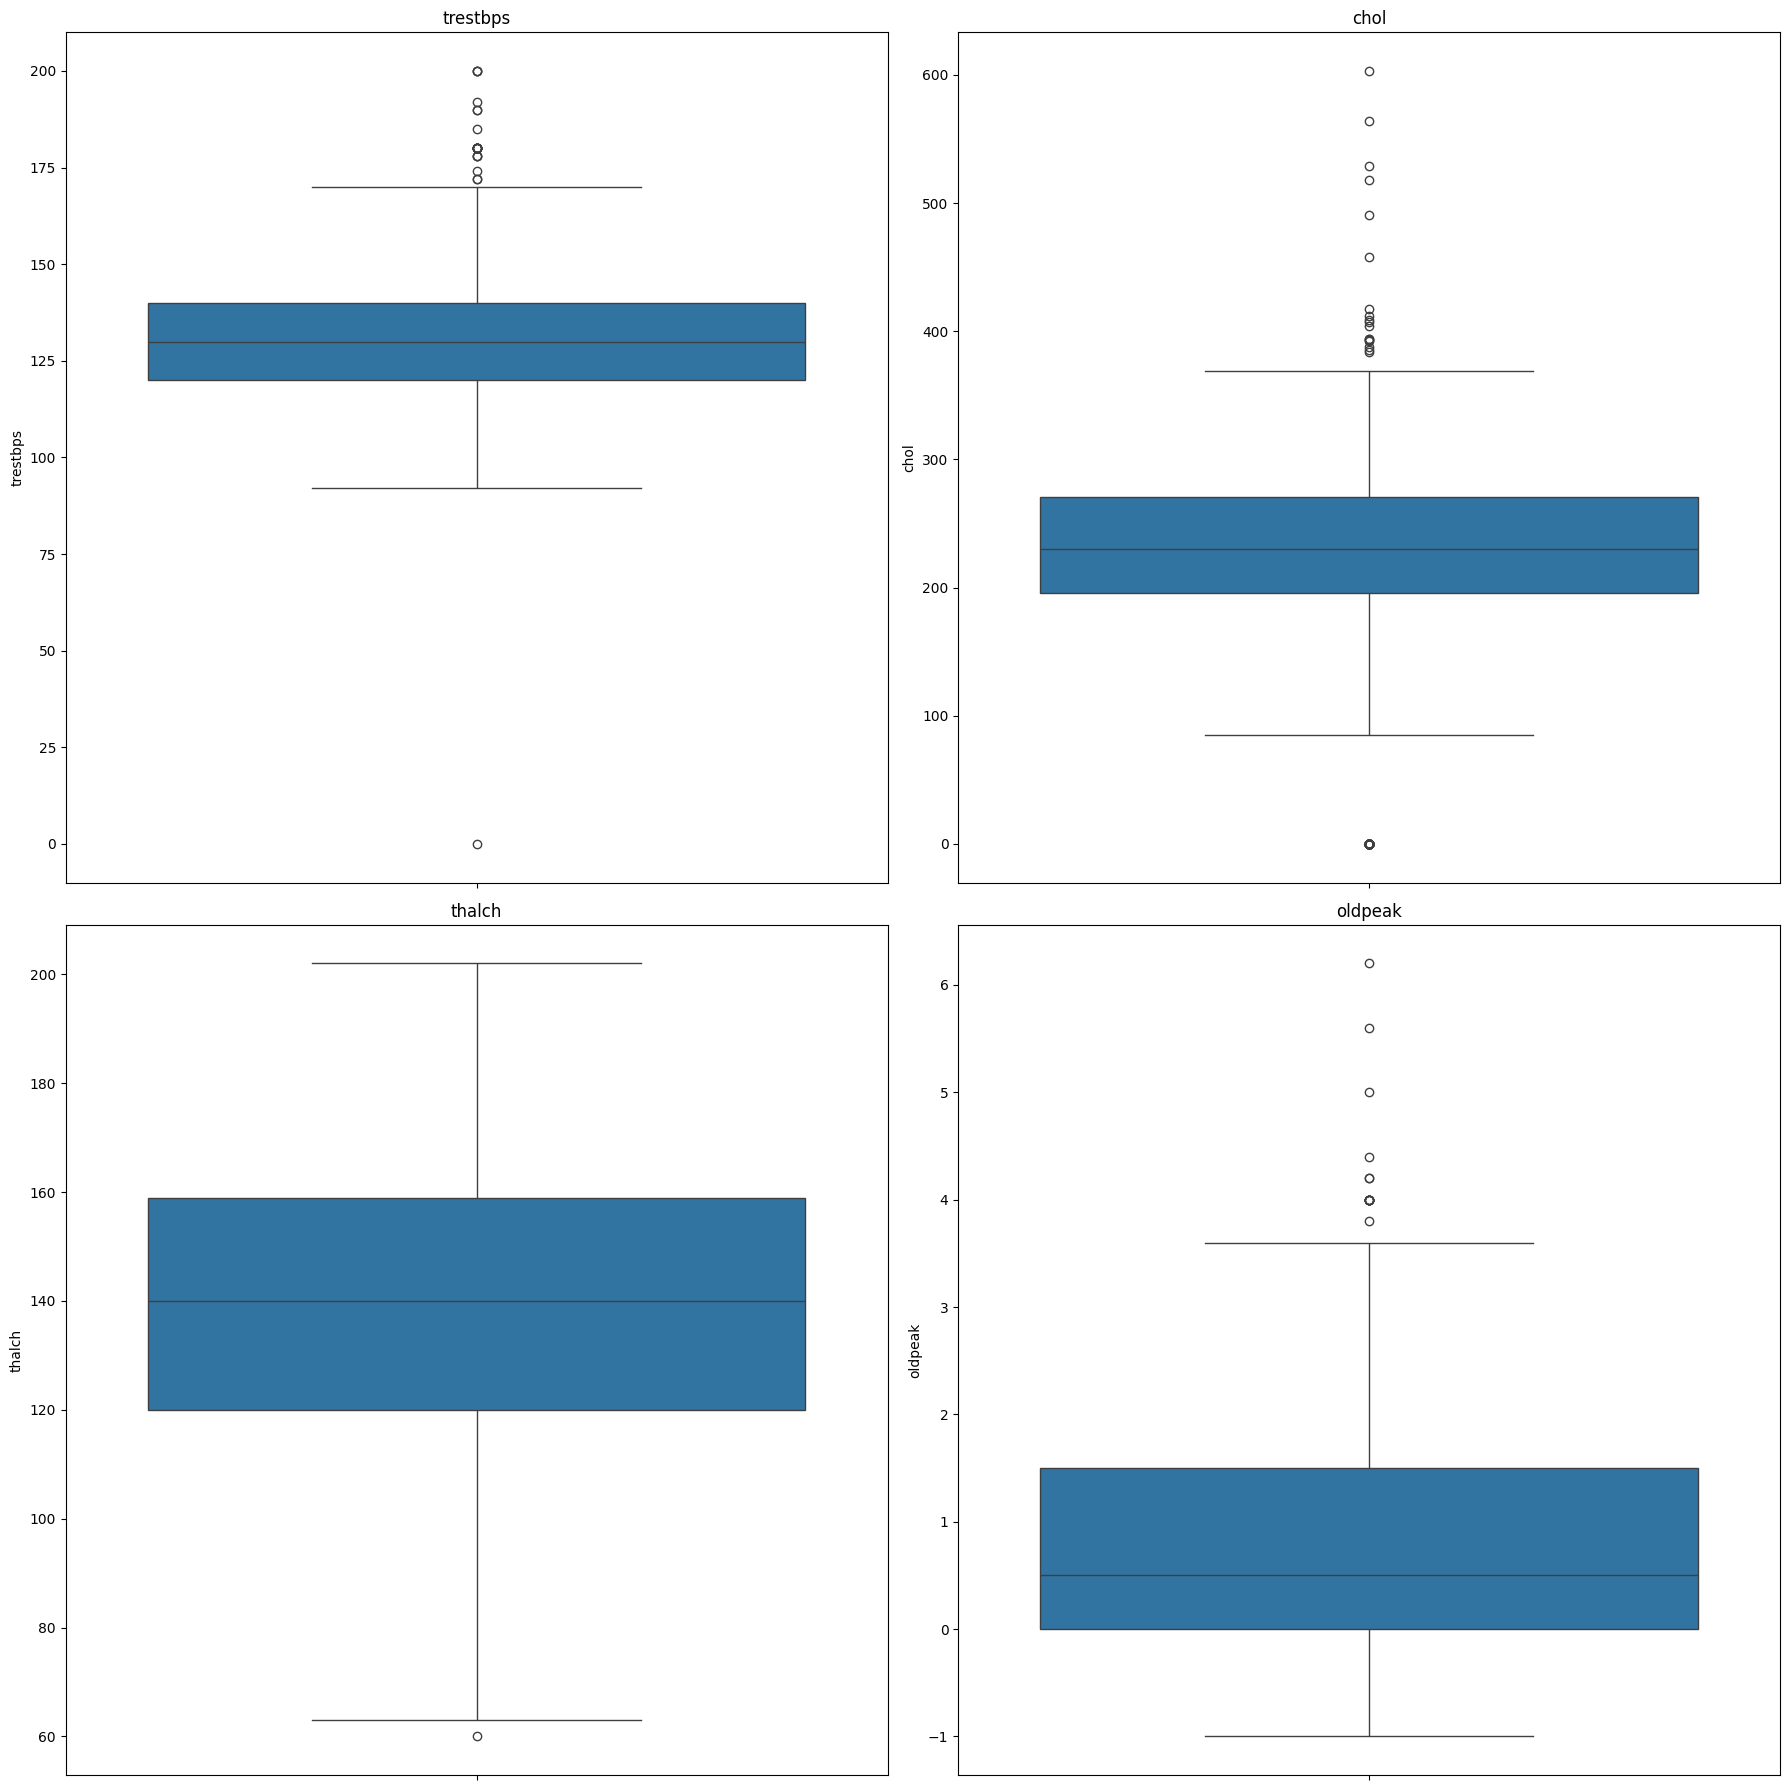

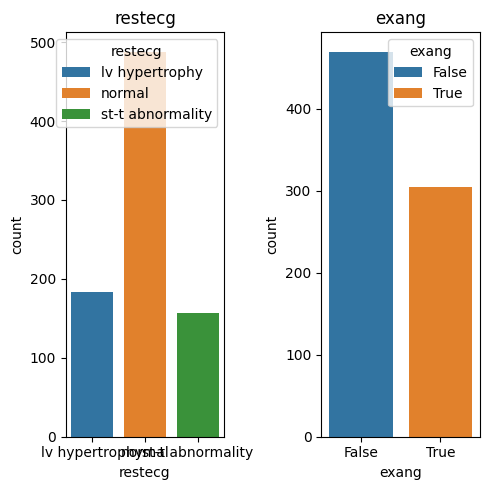

In [82]:
fig, axes =plt.subplots(2,2, figsize=(18,18))
cols1 =df[['trestbps','chol','thalch','oldpeak']]
cols2 =df[['restecg','exang']]
for ax1, col2 in zip(axes.flatten(), cols1):
    sns.boxplot(data =df, y= col2, ax=ax1)
    ax1.set_title(col2)
plt.tight_layout()
plt.show()
fig, axes =plt.subplots(1,2, figsize=(5,5))
for ax2, col2 in zip(axes.flatten(), cols2):
    sns.countplot(data =df, x =col2, hue =col2, ax =ax2)
    ax2.set_title(col2)
plt.tight_layout()
plt.show()

In [83]:
df=df.dropna(subset = 'exang')
df.shape
df.isna().sum()

id           0
age          0
sex          0
dataset      0
cp           0
trestbps     3
chol        27
fbs          0
restecg      1
thalch       0
exang        0
oldpeak      4
slope        0
num          0
dtype: int64

In [84]:
chol_med =df['chol'].median()
print(chol_med)
df['chol']=df['chol'].fillna(chol_med)
rest_med =df['trestbps'].median()
df['trestbps']=df['trestbps'].fillna(rest_med)
peak_med =df['oldpeak'].median()
df['oldpeak']=df['oldpeak'].fillna(peak_med)
df.isna().sum()

230.5


id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [85]:
df['restecg']=df['restecg'].fillna('normal')
df.isna().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64

In [86]:
df['sex'].unique()
df.shape

(775, 14)

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = df.select_dtypes(include='number').columns.difference(['sex_encode','exang_encode','num'])
cat_cols = df.select_dtypes(include=['object', 'category']).columns
scaler =StandardScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])
encoder =OneHotEncoder(sparse_output =False,drop = 'first')
encoded_cats =encoder.fit_transform(df[cat_cols])


In [88]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'num'],
      dtype='object')

In [89]:
df_encoded=pd.DataFrame(encoded_cats, columns =encoder.get_feature_names_out(cat_cols),index = df.index)
df_final=pd.concat([df_encoded, df[num_cols]], axis =1)
df_final=pd.concat([df_final, df['num']], axis =1)
df_final.head(10)


,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,...,slope_flat,slope_unknown,slope_upsloping,age,chol,id,oldpeak,thalch,trestbps,num
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.053870,0.144162,-1.592402,1.309708,0.439424,0.658320,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.478541,0.716919,-1.588541,0.569625,-1.190020,1.466703,2
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.478541,0.100935,-1.584680,1.587239,-0.375298,-0.688986,1
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,-1.706494,0.327876,-1.580819,2.419832,1.874887,-0.150064,0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-1.281823,-0.169234,-1.576958,0.477115,1.292942,-0.150064,0
5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.310695,0.176582,-1.573097,-0.077947,1.525720,-0.688986,0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.947702,0.522398,-1.569236,2.512342,0.827387,0.388859,3
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.416863,1.451777,-1.565375,-0.262968,0.943776,-0.688986,0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.053870,0.371103,-1.561514,0.477115,0.323035,-0.150064,2
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,-0.007808,-0.180040,-1.557653,2.049791,0.633406,0.388859,1


In [90]:

df_final.columns

Index(['sex_Male', 'dataset_Hungary', 'dataset_Switzerland',
       'dataset_VA Long Beach', 'cp_atypical angina', 'cp_non-anginal',
       'cp_typical angina', 'fbs_True', 'restecg_normal',
       'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_unknown',
       'slope_upsloping', 'age', 'chol', 'id', 'oldpeak', 'thalch', 'trestbps',
       'num'],
      dtype='object')

In [91]:
df_final=df_final.drop(columns ='id')
df_final['num']=df_final['num'].map({0 :0, 1:1, 2:1, 3:1, 4:1})

In [92]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 919
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sex_Male                  775 non-null    float64
 1   dataset_Hungary           775 non-null    float64
 2   dataset_Switzerland       775 non-null    float64
 3   dataset_VA Long Beach     775 non-null    float64
 4   cp_atypical angina        775 non-null    float64
 5   cp_non-anginal            775 non-null    float64
 6   cp_typical angina         775 non-null    float64
 7   fbs_True                  775 non-null    float64
 8   restecg_normal            775 non-null    float64
 9   restecg_st-t abnormality  775 non-null    float64
 10  exang_True                775 non-null    float64
 11  slope_flat                775 non-null    float64
 12  slope_unknown             775 non-null    float64
 13  slope_upsloping           775 non-null    float64
 14  age            

2. Model Training:

Split the dataset into a training set and a testing set.
Train a logistic regression model on the training set.

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
print(df_final.shape)
X = df_final.drop(columns ='num')
y =df_final['num']
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model=LogisticRegression()
model.fit(X_train, y_train)
y_pred =model.predict(X_test)



(775, 20)


3. Model Evaluation:

Evaluate the model on the testing set using accuracy, precision, recall, and F1 score.
Use a confusion matrix to visualize the model’s performance.


In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy = {accuracy} \nPrecision = {precision} \nRecall = {recall} \nF1 = {f1}")

Accuracy = 0.832258064516129 
Precision = 0.8372208436724566 
Recall = 0.832258064516129 
F1 = 0.8312008674437517


From the metrics, there model ability to predict future trends is high though we expect recall to be around 90 and above percent.

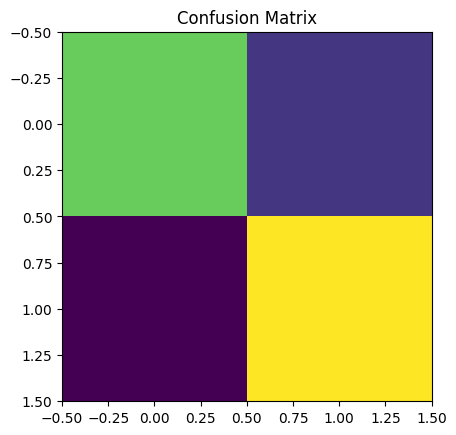

In [95]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.show()